# MZM KAN: SiLU vs Grid Resize

## Overview

Two ways to train the same spline KAN on the MZM regression problem (8
geometry features -> BW_3dB / IL / V_pi).

- **SiLU KAN.** `KANLinear` exactly as in `MZM_MLP.ipynb`. Every edge is
  `phi(x) = w_b * silu(x) + w_s * spline(x)` and the spline lives on a
  uniform grid of `G` intervals that never changes during the run.
- **Grid-resize KAN.** The same layer, silu base branch included. Training
  starts on a coarse grid and the grid is refined mid-run (grid extension,
  Liu et al. 2024, arXiv:2404.19756, Sec. 2.4). At each resize the new
  B-spline coefficients are the least-squares fit to the old spline, so the
  network computes the same function right after the resize and the finer
  grid only adds capacity. `MZM_MLP.ipynb` lists this as out of scope.

Every config below has the same widths as its final-grid counterpart, so
"resize" and "silu at the final grid" end with identical architectures and
identical parameter counts. Comparing those two isolates the effect of the
resize schedule. Comparing either one to the G=5 default shows what a finer
grid buys.

| Config | Grid during training | Hidden widths | Params |
|---|---|---|---|
| `silu_g5` | 5 | repo default, matched to Base MLP5's 336,253 | ~336k |
| `silu_g20` | 20 | re-matched to 336,253 at G=20 | ~336k |
| `resize` | 5 -> 10 -> 20 (20 / 20 / 60 epochs) | same as `silu_g20` | ~336k at the end |

Studies, in order: a resize sanity check, canonical runs, a fixed-grid
sweep, a resize-schedule ablation, bootstrap variance, data efficiency, and
timing.

**Protocol.** All runs share a 100-epoch budget, patience 15 (per stage for
resize), AdamW (lr 1e-3, wd 0.05), batch 16. Early stopping, best-weight
restore and stage hand-over use a 10% validation slice carved from the
*train* set, and the network trains on the other 90%. The test set only gets
scored. The earlier KAN notebooks stopped on the test set, so absolute
numbers here are not comparable to theirs; compare configs within this
notebook.

**Caveats.**
- Optimizer state restarts at every resize. Weights carry over, Adam
  moments do not.
- The grid stays uniform on `GRID_RANGE = (-2, 2)`. Only the density
  changes. pykan's adaptive grid placement from sample quantiles is not
  implemented.
- Few seeds. Read differences against the printed std, not against the
  mean alone.
- The learning rate is constant, so validation loss is spiky epoch to epoch
  (often 2-5x). Picking the best-validation epoch is therefore slightly
  optimistic on validation and noisy on test, for every config alike.
  `train` in the canonical table is the train loss at that same selected
  epoch.

## Setup

In [1]:
# ==============================
# Import Required Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from functools import lru_cache
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import re
import time

from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import optax
from flax import nnx

# Reproducibility
random_state = 123
np.random.seed(random_state)

## Model Definitions

`KANLinear` and `KANStack` are unchanged from `MZM_KAN_Variants_Comparison.ipynb`.
`KANLinear` keeps its knot vector as a static tuple, so changing the grid
means building a new layer and moving the weights across. That is what the
next section does.

In [2]:
GRID_RANGE = (-2.0, 2.0)
SPLINE_ORDER = 3


class KANLinear(nnx.Module):
    """A single KAN layer: an n_in x n_out matrix of learnable 1D edge
    functions phi(x) = w_b * silu(x) + w_s * spline(x) (Liu et al. 2024,
    arXiv:2404.19756, Eq. 2.5/2.10-2.12). Unchanged from MZM_MLP.ipynb."""

    def __init__(
        self, in_features, out_features, grid_size=5, spline_order=3,
        grid_range=GRID_RANGE, *, rngs: nnx.Rngs,
    ):
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.grid_range = grid_range

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = np.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        self.knots = tuple(float(v) for v in grid)

        he = jax.nn.initializers.he_uniform()
        num_basis = grid_size + spline_order
        self.base_weight = nnx.Param(he(rngs.params(), (out_features, in_features)))
        self.spline_scaler = nnx.Param(jnp.ones((out_features, in_features)))
        self.spline_weight = nnx.Param(
            jax.random.normal(rngs.params(), (out_features, in_features, num_basis)) * 0.1
        )

    def _b_splines(self, x):
        knots = jnp.asarray(self.knots, dtype=x.dtype)
        xc = jnp.clip(x, self.grid_range[0], self.grid_range[1])[..., None]
        bases = ((xc >= knots[:-1]) & (xc < knots[1:])).astype(x.dtype)
        for order in range(1, self.spline_order + 1):
            left = (xc - knots[: -order - 1]) / (knots[order:-1] - knots[: -order - 1])
            right = (knots[order + 1:] - xc) / (knots[order + 1:] - knots[1:-order])
            bases = left * bases[..., :-1] + right * bases[..., 1:]
        return bases

    def __call__(self, x, *, train: bool = False, rngs=None):
        base_out = jax.nn.silu(x) @ self.base_weight[...].T
        bases = self._b_splines(x)
        weighted = self.spline_weight[...] * self.spline_scaler[...][..., None]
        spline_out = jnp.einsum("oik,...ik->...o", weighted, bases)
        return base_out + spline_out, {}


class KANStack(nnx.Module):
    """KAN(x) = (Phi_{L-1} o ... o Phi_0)(x) (Eq. 2.7) over
    `dims = (input_dim, *hidden_dims, output_dim)`."""

    def __init__(self, layer_cls, dims, *, rngs: nnx.Rngs, **layer_kwargs):
        self.layers = nnx.data([
            layer_cls(d_in, d_out, rngs=rngs, **layer_kwargs)
            for d_in, d_out in zip(dims[:-1], dims[1:])
        ])

    def __call__(self, x, *, train: bool = False, rngs=None):
        for layer in self.layers:
            x, _ = layer(x, train=train, rngs=rngs)
        return x, {}


def _kan_ctor(dims, grid_size):
    return lambda rngs: KANStack(
        KANLinear, (8, *dims, 3), grid_size=grid_size, spline_order=SPLINE_ORDER, rngs=rngs)

## Grid Resize

Take one edge with spline `s_old(x) = sum_j c_j B_j^old(x)` on `G` intervals.
Sample `N` points `x_n` on `GRID_RANGE` and solve

`min_c' || B_new c' - B_old c ||^2`, so `c' = pinv(B_new) B_old c`.

`B_old` is `(N, G+k)`, `B_new` is `(N, G'+k)`. The matrix
`T = pinv(B_new) B_old` of shape `(G'+k, G+k)` is the same for every edge
(one shared uniform grid), so resizing a whole layer is one einsum,
`w_new = w_old @ T.T`, applied to the last axis of `spline_weight`. The silu
base weight, the spline scaler and every other parameter are copied as they
are.

When the new grid nests the old one (`G'` a multiple of `G`) the old spline
lies exactly inside the new spline space and the fit is exact up to float
error. Otherwise the fit is a projection and leaves a small residual. Any
`G'` works, including a smaller one, so the same code also shrinks a grid.

In [3]:
@lru_cache(maxsize=None)
def resize_matrix(g_old, g_new, k=SPLINE_ORDER, n_pts=None):
    """T of shape (g_new+k, g_old+k): new spline coefficients = T @ old ones."""
    n_pts = n_pts or 32 * (g_new + k)
    xs = jnp.linspace(GRID_RANGE[0], GRID_RANGE[1], n_pts)[:, None]
    b_old = KANLinear(1, 1, g_old, k, rngs=nnx.Rngs(0))._b_splines(xs)[:, 0, :]
    b_new = KANLinear(1, 1, g_new, k, rngs=nnx.Rngs(0))._b_splines(xs)[:, 0, :]
    T = np.linalg.lstsq(np.asarray(b_new, np.float64), np.asarray(b_old, np.float64), rcond=None)[0]
    return jnp.asarray(T, dtype=jnp.float32)


def resize_pure(pure, T):
    """Apply T to every `spline_weight` in a pure-dict param tree
    (nnx.to_pure_dict output); every other leaf is copied unchanged."""
    out = {}
    for name, v in pure.items():
        if isinstance(v, dict):
            out[name] = resize_pure(v, T)
        elif name == "spline_weight":
            out[name] = jnp.einsum("oik,jk->oij", v, T)
        else:
            out[name] = v
    return out

### Sanity check: the resize preserves the function

Random 3-layer KAN at G=5, resized to a nested grid (10, 20) and to
non-nested grids (8, 7). Output difference on random inputs, next to the
output's own RMS.

In [4]:
_dims = (8, 40, 50, 3)
_m5 = KANStack(KANLinear, _dims, grid_size=5, rngs=nnx.Rngs(1))
_gd5, _p5 = nnx.split(_m5, nnx.Param)
_pure5 = nnx.to_pure_dict(_p5)
_x = jax.random.uniform(jax.random.PRNGKey(0), (2000, 8))
_y5 = _m5(_x)[0]
print(f"output RMS: {float(jnp.sqrt(jnp.mean(_y5 ** 2))):.3f}")

for g_new in (10, 20, 8, 7):
    _m = KANStack(KANLinear, _dims, grid_size=g_new, rngs=nnx.Rngs(2))
    _gd, _p = nnx.split(_m, nnx.Param)
    nnx.replace_by_pure_dict(_p, resize_pure(_pure5, resize_matrix(5, g_new)))
    err = float(jnp.max(jnp.abs(nnx.merge(_gd, _p)(_x)[0] - _y5)))
    kind = "nested    " if g_new % 5 == 0 else "non-nested"
    print(f"G 5 -> {g_new:2d} ({kind}): max |diff| = {err:.2e}")
    if g_new % 5 == 0:
        assert err < 1e-4, "nested resize should be exact up to float error"

output RMS: 1.871


G 5 -> 10 (nested    ): max |diff| = 2.56e-06


G 5 -> 20 (nested    ): max |diff| = 2.15e-06


G 5 ->  8 (non-nested): max |diff| = 4.74e-02


G 5 ->  7 (non-nested): max |diff| = 9.49e-02


## Data Loading & Preprocessing

Same pipeline as the other notebooks, plus a fixed 10% validation slice
carved from the train set (seed 123) for early stopping and stage hand-over.

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/MZM Data/Sim_generated_dataset.txt"
file_path = "Sim_generated_dataset.txt"

In [6]:
with open(file_path) as f:
    cleaned = [re.sub(r'[\[\]]', '', line.strip()) for line in f]

df = pd.read_csv(StringIO("\n".join(cleaned)), header=None)
df.columns = [
    "PN_offset", "Bias_V", "Core_width", "P+_width", "N+_width",
    "P_width", "N_width", "Phase_length", "BW_3dB", "IL", "V_pi"
]

# Data cleaning: remove rows with extreme V_pi (>500, <0)
df_cleaned = df[(df['V_pi'] < 500) & (df['V_pi'] > 0)].copy()
print(f"Dataset size after cleaning: {len(df_cleaned)} samples")

# Split features / targets
feature_cols = df_cleaned.columns[:8]
target_cols = df_cleaned.columns[8:]

x = df_cleaned[feature_cols].values
y = df_cleaned[target_cols].values

# Train / test split
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    x, y, test_size=0.1, random_state=random_state
)

# ==============================
# Scaling (fit on TRAIN only)
# ==============================
scaler_x = MinMaxScaler()  # Features
scaler_y1 = StandardScaler()  # BW_3dB
scaler_y2 = StandardScaler()  # IL
scaler_y3 = StandardScaler()  # V_pi

x_train_scaled = scaler_x.fit_transform(x_train_raw)
y_train_scaled = np.hstack([
    scaler_y1.fit_transform(y_train_raw[:, 0:1]),
    scaler_y2.fit_transform(y_train_raw[:, 1:2]),
    scaler_y3.fit_transform(y_train_raw[:, 2:3]),
])

x_test_scaled = scaler_x.transform(x_test_raw)
y_test_scaled = np.hstack([
    scaler_y1.transform(y_test_raw[:, 0:1]),
    scaler_y2.transform(y_test_raw[:, 1:2]),
    scaler_y3.transform(y_test_raw[:, 2:3]),
])

# Convert to tensors
x_train_t = jnp.asarray(x_train_scaled, dtype=jnp.float32)
y_train_t = jnp.asarray(y_train_scaled, dtype=jnp.float32)
x_test_t  = jnp.asarray(x_test_scaled, dtype=jnp.float32)
y_test_t  = jnp.asarray(y_test_scaled, dtype=jnp.float32)

# Validation slice carved from TRAIN (test set is never used for selection)
n_full = x_train_t.shape[0]
_perm = np.random.default_rng(random_state).permutation(n_full)
_n_val = int(round(0.1 * n_full))
val_idx, fit_idx = _perm[:_n_val], _perm[_n_val:]
x_fit, y_fit = x_train_t[fit_idx], y_train_t[fit_idx]
x_val, y_val = x_train_t[val_idx], y_train_t[val_idx]

print(f"fit: {x_fit.shape[0]} | val: {x_val.shape[0]} | test: {x_test_t.shape[0]}")

Dataset size after cleaning: 9614 samples


fit: 7787 | val: 865 | test: 962


## GPU Setup

In [7]:
print(f"JAX devices: {jax.devices()}")
print(f"Using backend: {jax.default_backend()}")
print(f"x_fit device: {x_fit.device}")

JAX devices: [CudaDevice(id=0)]
Using backend: gpu
x_fit device: cuda:0


## Width Matching

Parameters per KAN layer are `n_in * n_out * (G + k + 2)`: `G + k` spline
coefficients plus the silu weight and the spline scaler. That is closed
form, so width matching bisects on a formula instead of building models.
The scale factor multiplies Base MLP5's shape `(200, 300, 350, 300, 200)`,
the same expand-to-peak-then-shrink template as the other notebooks. A
finer grid costs more per edge, so the matched width shrinks as `G` grows.

In [8]:
BASE_N_PARAMS = 336_253  # Base MLP5's default, the target used across the KAN notebooks
_SHAPE_TEMPLATE = (200, 300, 350, 300, 200)


def kan_n_params(dims, grid_size, spline_order=SPLINE_ORDER):
    sizes = (8, *dims, 3)
    return sum(a * b * (grid_size + spline_order + 2) for a, b in zip(sizes[:-1], sizes[1:]))


def kan_scale_matching(grid_size, target_params=BASE_N_PARAMS, lo=0.01, hi=3.0, iters=40):
    dims_for = lambda s: tuple(max(2, round(d * s)) for d in _SHAPE_TEMPLATE)
    for _ in range(iters):
        mid = (lo + hi) / 2
        if kan_n_params(dims_for(mid), grid_size) < target_params:
            lo = mid
        else:
            hi = mid
    dims = dims_for((lo + hi) / 2)
    return dims, kan_n_params(dims, grid_size)


# the closed form must agree with the real model
_d, _n = kan_scale_matching(20)
_, _p = nnx.split(_kan_ctor(_d, 20)(nnx.Rngs(0)), nnx.Param)
assert _n == sum(a.size for a in jax.tree_util.tree_leaves(_p))

for g in (3, 5, 10, 20, 40):
    d, n = kan_scale_matching(g)
    print(f"G={g:>2d}  dims={str(d):26s} n_params={n:>7d} ({(n - BASE_N_PARAMS) / BASE_N_PARAMS * 100:+.2f}%)")

G= 3  dims=(71, 106, 124, 106, 71)    n_params= 336968 (+0.21%)
G= 5  dims=(63, 95, 110, 95, 63)      n_params= 335630 (-0.19%)
G=10  dims=(51, 77, 90, 77, 51)       n_params= 334125 (-0.63%)
G=20  dims=(40, 59, 69, 59, 40)       n_params= 332550 (-1.10%)
G=40  dims=(30, 44, 52, 44, 30)       n_params= 339570 (+0.99%)


## Training Function

`train_kan(dims, stages)` takes `stages = ((grid_size, max_epochs), ...)`.
A fixed-grid run is a single stage. For a resize run, each stage:

1. builds the model at that stage's grid (stage 0 from the seeded init, later
   stages from the previous stage's best weights through `resize_pure`),
2. trains with a fresh AdamW state,
3. stops on its epoch budget or on patience, restores its best-validation
   weights, and hands them to the next stage.

Each epoch runs as one `jax.lax.scan` under `jit`, as in the other
notebooks (drop-last batching). `val_at_start` in the stage log is the
validation loss measured right after the resize, before any training in the
new stage. It should equal the previous stage's best validation loss when the
resize is exact.

In [9]:
def _make_stage(dims, grid_size, x_tr, y_tr, *, batch_size, learning_rate, weight_decay, init_key):
    """Model + optimizer + jitted epoch/eval functions for one grid size."""
    graphdef, params = nnx.split(_kan_ctor(dims, grid_size)(nnx.Rngs(init_key)), nnx.Param)
    tx = optax.adamw(learning_rate, weight_decay=weight_decay, b1=0.9, b2=0.999)
    n_train = x_tr.shape[0]
    n_batches = max(n_train // batch_size, 1)

    def loss_fn(params, x, y):
        pred, _ = nnx.merge(graphdef, params)(x, train=True)
        return jnp.mean((pred - y) ** 2)

    @jax.jit
    def run_epoch(params, opt_state, perm):
        batch_idx = perm[: n_batches * batch_size].reshape(n_batches, batch_size)

        def step(carry, idx):
            params, opt_state = carry
            grads = jax.grad(loss_fn)(params, x_tr[idx], y_tr[idx])
            updates, opt_state = tx.update(grads, opt_state, params)
            return (optax.apply_updates(params, updates), opt_state), None

        (params, opt_state), _ = jax.lax.scan(step, (params, opt_state), batch_idx)
        return params, opt_state

    @jax.jit
    def eval_loss(params, x, y):
        pred, _ = nnx.merge(graphdef, params)(x, train=False)
        return jnp.mean((pred - y) ** 2)

    return params, tx.init(params), run_epoch, eval_loss


def train_kan(
    dims, stages, *, batch_size=16, learning_rate=1e-3, weight_decay=0.05,
    patience=15, min_delta=1e-5, seed=random_state, x_train=None, y_train=None,
):
    """Train a SiLU KAN through a grid schedule. Selection uses the
    validation slice; the test loss is recorded at the selected weights."""
    x_tr = x_fit if x_train is None else x_train
    y_tr = y_fit if y_train is None else y_train
    n_train = x_tr.shape[0]
    init_key, epoch_key = jax.random.split(jax.random.PRNGKey(seed))

    hist = {"train": [], "val": [], "test": []}
    stage_log = []
    pure, prev_g = None, None
    t_start = time.perf_counter()

    for g, n_ep in stages:
        params, opt_state, run_epoch, eval_loss = _make_stage(
            dims, g, x_tr, y_tr, batch_size=batch_size, learning_rate=learning_rate,
            weight_decay=weight_decay, init_key=init_key)
        if pure is not None:
            _, template = nnx.split(_kan_ctor(dims, g)(nnx.Rngs(init_key)), nnx.Param)
            nnx.replace_by_pure_dict(template, resize_pure(pure, resize_matrix(prev_g, g)))
            params = template
            opt_state = optax.adamw(learning_rate, weight_decay=weight_decay).init(params)

        n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))
        val_at_start = float(eval_loss(params, x_val, y_val))
        best = dict(val=np.inf, test=np.inf, epoch=-1, params=params)
        wait, start_epoch = 0, len(hist["val"])

        for ep in range(n_ep):
            epoch_key, perm_key = jax.random.split(epoch_key)
            perm = jax.random.permutation(perm_key, n_train)
            params, opt_state = run_epoch(params, opt_state, perm)

            tr = float(eval_loss(params, x_tr, y_tr))
            va = float(eval_loss(params, x_val, y_val))
            te = float(eval_loss(params, x_test_t, y_test_t))
            hist["train"].append(tr); hist["val"].append(va); hist["test"].append(te)

            if va < best["val"] - min_delta:
                best = dict(val=va, test=te, epoch=ep, params=params)
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break

        params = best["params"]
        stage_log.append(dict(
            grid=g, n_params=n_params, start_epoch=start_epoch, epochs=ep + 1,
            best_epoch=best["epoch"], val_at_start=val_at_start, best_val=best["val"],
            best_test=best["test"],
        ))
        pure, prev_g = nnx.to_pure_dict(params), g

    final = stage_log[-1]
    return {
        "n_params": final["n_params"],
        "val_loss": final["best_val"],
        "test_loss": final["best_test"],
        "epochs": len(hist["val"]),
        "time_s": time.perf_counter() - t_start,
        "hist": {k: np.array(v) for k, v in hist.items()},
        "stages": stage_log,
    }

## Config Registry

`schedule(grids)` splits the 100-epoch budget: every stage but the last gets
20 epochs, the last gets the remainder. `run(...)` memoizes on its
arguments, so a config that appears in several studies (same dims, schedule
and seed) trains once.

In [10]:
TOTAL_EPOCHS = 100
WARM_EPOCHS = 20
G_FINAL = 20
PATIENCE = 15


def schedule(grids, total=TOTAL_EPOCHS, warm=WARM_EPOCHS):
    return tuple((g, warm) for g in grids[:-1]) + ((grids[-1], total - warm * (len(grids) - 1)),)


DIMS_BY_G = {g: kan_scale_matching(g)[0] for g in (3, 5, 10, 20, 40)}

CONFIGS = {
    "silu_g5":  dict(dims=DIMS_BY_G[5],       stages=schedule([5]),          label="SiLU KAN, G=5"),
    "silu_g20": dict(dims=DIMS_BY_G[G_FINAL], stages=schedule([G_FINAL]),    label="SiLU KAN, G=20"),
    "resize":   dict(dims=DIMS_BY_G[G_FINAL], stages=schedule([5, 10, 20]),  label="Grid-resize KAN, G=5>10>20"),
}
COLOR = {"silu_g5": "#3477eb", "silu_g20": "#eb6834", "resize": "#2ca02c"}
LS    = {"silu_g5": "-",       "silu_g20": "--",       "resize": "-"}
MARK  = {"silu_g5": "o",       "silu_g20": "s",        "resize": "^"}
NAMES = list(CONFIGS)

_RUNS = {}


def run(dims, stages, *, seed=123, frac=1.0, bootstrap=False, patience=PATIENCE):
    """Train on the fit split, optionally bootstrap-resampled (with
    replacement, same size) or subsampled (frac<1, without replacement)."""
    key = (tuple(dims), tuple(stages), seed, frac, bootstrap, patience)
    if key not in _RUNS:
        rng = np.random.default_rng(seed)
        x_tr, y_tr = x_fit, y_fit
        n = x_fit.shape[0]
        if bootstrap:
            idx = rng.integers(0, n, size=n)
            x_tr, y_tr = x_tr[idx], y_tr[idx]
        elif frac < 1.0:
            idx = rng.choice(n, size=max(int(round(n * frac)), 32), replace=False)
            x_tr, y_tr = x_tr[idx], y_tr[idx]
        _RUNS[key] = train_kan(dims, stages, patience=patience, seed=seed, x_train=x_tr, y_train=y_tr)
    return _RUNS[key]


def run_cfg(name, **kw):
    return run(CONFIGS[name]["dims"], CONFIGS[name]["stages"], **kw)


for name, c in CONFIGS.items():
    print(f"{name:9s} dims={str(c['dims']):26s} stages={c['stages']} n_params(final)={kan_n_params(c['dims'], c['stages'][-1][0])}")

silu_g5   dims=(63, 95, 110, 95, 63)      stages=((5, 100),) n_params(final)=335630
silu_g20  dims=(40, 59, 69, 59, 40)       stages=((20, 100),) n_params(final)=332550
resize    dims=(40, 59, 69, 59, 40)       stages=((5, 20), (10, 20), (20, 60)) n_params(final)=332550


## Canonical Runs

One seed (123), all three configs. Left panel: validation loss over
epochs, with the resize run's stage boundaries marked. Right panel: test loss
at the selected weights.

In [11]:
canonical = {name: run_cfg(name, seed=123) for name in NAMES}

print(f"{'config':9s} {'n_params':>8s} {'epochs':>6s} {'train':>9s} {'val':>9s} {'test':>9s} {'time[s]':>8s}")
for name, r in canonical.items():
    _last = r["stages"][-1]
    _train_at_best = r["hist"]["train"][_last["start_epoch"] + _last["best_epoch"]]
    print(f"{name:9s} {r['n_params']:>8d} {r['epochs']:>6d} {_train_at_best:>9.5f} "
          f"{r['val_loss']:>9.5f} {r['test_loss']:>9.5f} {r['time_s']:>8.1f}")

print("\nResize run, per stage:")
print(f"{'grid':>4s} {'n_params':>8s} {'epochs':>6s} {'val at start':>13s} {'best val':>9s} {'best test':>10s}")
for s in canonical["resize"]["stages"]:
    print(f"{s['grid']:>4d} {s['n_params']:>8d} {s['epochs']:>6d} {s['val_at_start']:>13.5f} {s['best_val']:>9.5f} {s['best_test']:>10.5f}")

config    n_params epochs     train       val      test  time[s]
silu_g5     335630     77   0.01429   0.00684   0.00714     23.8
silu_g20    332550     50   0.01373   0.00808   0.00936     15.6
resize      332550    100   0.00873   0.00598   0.00622     35.3

Resize run, per stage:
grid n_params epochs  val at start  best val  best test
   5   133020     20       3.07832   0.01409    0.01572
  10   199530     20       0.01409   0.00742    0.00802
  20   332550     60       0.00742   0.00598    0.00622


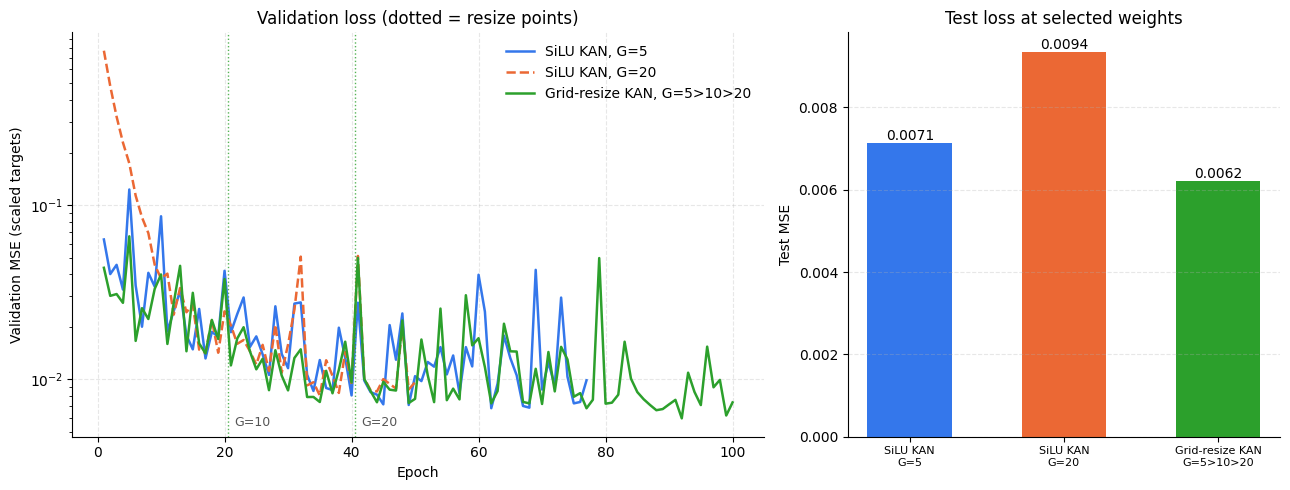

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.6, 1]})

ax = axs[0]
for name in NAMES:
    r = canonical[name]
    ax.plot(np.arange(1, r["epochs"] + 1), r["hist"]["val"], color=COLOR[name], ls=LS[name],
            lw=1.8, label=CONFIGS[name]["label"])
for s in canonical["resize"]["stages"][1:]:
    ax.axvline(s["start_epoch"] + 0.5, color=COLOR["resize"], lw=1, ls=":", alpha=0.8)
    ax.text(s["start_epoch"] + 1.5, 0.02, f"G={s['grid']}", color="#555", fontsize=9, va="bottom",
            transform=ax.get_xaxis_transform())
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation MSE (scaled targets)")
ax.set_title("Validation loss (dotted = resize points)")
ax.grid(True, ls="--", alpha=0.3)
ax.legend(frameon=False)

ax = axs[1]
vals = [canonical[n]["test_loss"] for n in NAMES]
bars = ax.bar([CONFIGS[n]["label"].replace(", G=", "\nG=") for n in NAMES], vals,
              color=[COLOR[n] for n in NAMES], width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Test MSE")
ax.set_title("Test loss at selected weights")
ax.grid(True, ls="--", alpha=0.3, axis="y")
ax.tick_params(axis="x", labelsize=8)

for a in axs:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Fixed-Grid Sweep

Is a finer grid worth it at all? SiLU KAN at `G` in {3, 5, 10, 20, 40}, each
width re-matched to ~336k params, 3 seeds. The grid-resize result is
overlaid at G=20, its final grid.

In [13]:
SEEDS = (123, 124, 125)
GRID_SWEEP = (3, 5, 10, 20, 40)

sweep = {g: [run(DIMS_BY_G[g], schedule([g]), seed=s) for s in SEEDS] for g in GRID_SWEEP}
resize_seeds = [run_cfg("resize", seed=s) for s in SEEDS]

print(f"{'G':>3s} {'dims':26s} {'n_params':>8s} {'test mean':>10s} {'test std':>9s} {'val mean':>9s}")
for g in GRID_SWEEP:
    te = np.array([r["test_loss"] for r in sweep[g]])
    va = np.array([r["val_loss"] for r in sweep[g]])
    print(f"{g:>3d} {str(DIMS_BY_G[g]):26s} {sweep[g][0]['n_params']:>8d} {te.mean():>10.5f} {te.std():>9.5f} {va.mean():>9.5f}")
te = np.array([r["test_loss"] for r in resize_seeds])
va = np.array([r["val_loss"] for r in resize_seeds])
print(f"{'20*':>3s} {str(DIMS_BY_G[20]):26s} {resize_seeds[0]['n_params']:>8d} {te.mean():>10.5f} {te.std():>9.5f} {va.mean():>9.5f}   (* grid-resize 5>10>20)")

  G dims                       n_params  test mean  test std  val mean
  3 (71, 106, 124, 106, 71)      336968    0.00851   0.00081   0.00773
  5 (63, 95, 110, 95, 63)        335630    0.00767   0.00081   0.00735
 10 (51, 77, 90, 77, 51)         334125    0.00758   0.00086   0.00680
 20 (40, 59, 69, 59, 40)         332550    0.00806   0.00113   0.00740
 40 (30, 44, 52, 44, 30)         339570    0.00757   0.00051   0.00700
20* (40, 59, 69, 59, 40)         332550    0.00685   0.00070   0.00658   (* grid-resize 5>10>20)


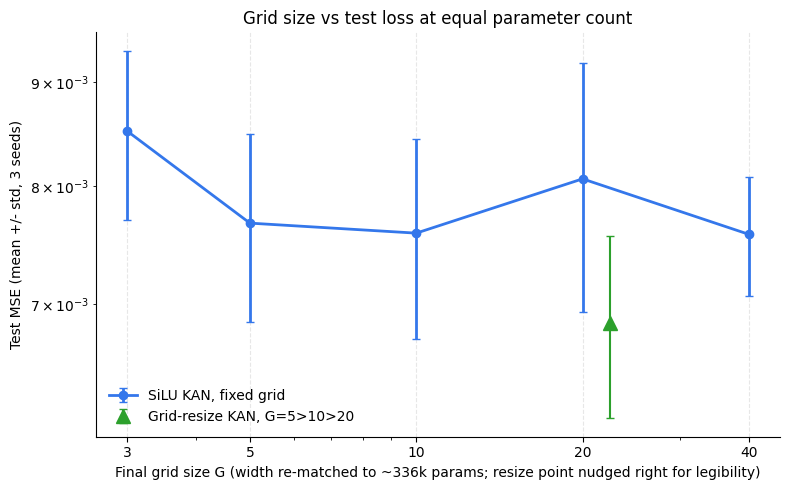

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
m = np.array([np.mean([r["test_loss"] for r in sweep[g]]) for g in GRID_SWEEP])
s = np.array([np.std([r["test_loss"] for r in sweep[g]]) for g in GRID_SWEEP])
ax.errorbar(GRID_SWEEP, m, yerr=s, color=COLOR["silu_g5"], lw=2, marker="o", ms=6, capsize=3,
            label="SiLU KAN, fixed grid")
rm = np.mean([r["test_loss"] for r in resize_seeds])
rs = np.std([r["test_loss"] for r in resize_seeds])
ax.errorbar([G_FINAL * 1.12], [rm], yerr=[rs], color=COLOR["resize"], marker="^", ms=10, capsize=3, ls="none",
            label="Grid-resize KAN, G=5>10>20")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(GRID_SWEEP)
ax.set_xticklabels(GRID_SWEEP)
ax.set_xlabel("Final grid size G (width re-matched to ~336k params; resize point nudged right for legibility)")
ax.set_ylabel("Test MSE (mean +/- std, 3 seeds)")
ax.set_title("Grid size vs test loss at equal parameter count")
ax.grid(True, ls="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Resize-Schedule Ablation

Same final architecture (G=20, matched widths), different paths to it. The
budget is 100 epochs in every case, 20 per early stage and the rest in the
last one. `20` is the plain fixed-grid run. `2>5>10>20` includes a
non-nested step (2 -> 5), where the least-squares fit is a projection and
the function changes slightly at that resize.

In [15]:
SCHEDULES = {
    "20":         [20],
    "10>20":      [10, 20],
    "5>10>20":    [5, 10, 20],
    "2>5>10>20":  [2, 5, 10, 20],
}
ablation = {k: [run(DIMS_BY_G[G_FINAL], schedule(g), seed=s) for s in SEEDS] for k, g in SCHEDULES.items()}

print(f"{'schedule':10s} {'test mean':>10s} {'test std':>9s} {'val mean':>9s} {'time[s] mean':>13s}")
for k, rs_ in ablation.items():
    te = np.array([r["test_loss"] for r in rs_])
    va = np.array([r["val_loss"] for r in rs_])
    print(f"{k:10s} {te.mean():>10.5f} {te.std():>9.5f} {va.mean():>9.5f} {np.mean([r['time_s'] for r in rs_]):>13.1f}")

print("\nGap at each resize (val loss right after resize / best val of the previous stage):")
for k, rs_ in ablation.items():
    if len(SCHEDULES[k]) == 1:
        continue
    ratios = [[st["val_at_start"] / prev["best_val"] for prev, st in zip(r["stages"][:-1], r["stages"][1:])] for r in rs_]
    print(f"  {k:10s} " + "  ".join(f"G={st['grid']}: {np.mean([row[i] for row in ratios]):.3f}x"
                                    for i, st in enumerate(rs_[0]["stages"][1:])))

schedule    test mean  test std  val mean  time[s] mean
20            0.00806   0.00113   0.00740          18.2
10>20         0.00778   0.00094   0.00744          17.8
5>10>20       0.00685   0.00070   0.00658          26.2
2>5>10>20     0.00665   0.00014   0.00640          28.1

Gap at each resize (val loss right after resize / best val of the previous stage):
  10>20      G=20: 1.000x
  5>10>20    G=10: 1.000x  G=20: 1.000x
  2>5>10>20  G=5: 1.001x  G=10: 1.000x  G=20: 1.000x


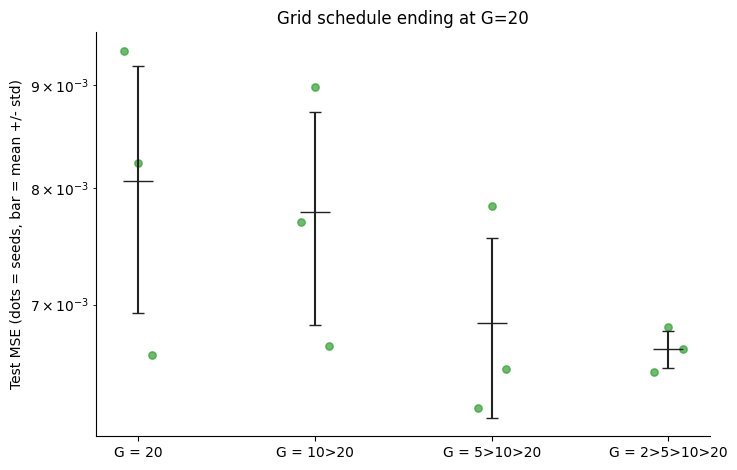

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
keys = list(SCHEDULES)
for i, k in enumerate(keys):
    te = np.array([r["test_loss"] for r in ablation[k]])
    ax.scatter(np.full(len(te), i) + np.linspace(-0.08, 0.08, len(te)), te, color=COLOR["resize"], s=28, alpha=0.7, zorder=3)
    ax.errorbar([i], [te.mean()], yerr=[te.std()], color="#222", marker="_", ms=22, capsize=4, lw=1.5, zorder=4)
ax.set_xticks(range(len(keys)))
ax.set_xticklabels([f"G = {k}" for k in keys])
ax.set_yscale("log")
ax.set_ylabel("Test MSE (dots = seeds, bar = mean +/- std)")
ax.set_title("Grid schedule ending at G=20")
ax.grid(True, ls="--", alpha=0.3, axis="y")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Bootstrap Variance

Each resample draws the fit split with replacement (same size) and trains all three configs on it with the
same seed, so the comparison is paired. Seeds `1000 + i`, `n_bootstrap = 10`.
Selection still uses the fixed validation slice, so the resample only
changes the training set.

In [17]:
n_bootstrap = 10
boot = {name: [] for name in NAMES}
for i in tqdm(range(n_bootstrap), desc="Bootstrap"):
    for name in NAMES:
        boot[name].append(run_cfg(name, seed=1000 + i, bootstrap=True)["test_loss"])
boot = {k: np.array(v) for k, v in boot.items()}

print(f"{'config':9s} {'mean':>9s} {'std':>9s} {'std/mean':>9s}")
for name in NAMES:
    print(f"{name:9s} {boot[name].mean():>9.5f} {boot[name].std():>9.5f} {boot[name].std() / boot[name].mean() * 100:>8.1f}%")

print("\nPaired difference in test loss (first minus second, negative = first is better):")
for a, b in (("resize", "silu_g20"), ("resize", "silu_g5"), ("silu_g20", "silu_g5")):
    d = boot[a] - boot[b]
    print(f"  {a:9s} - {b:9s}: mean {d.mean():+.5f}  std {d.std():.5f}  first wins {int((d < 0).sum())}/{n_bootstrap}")

Bootstrap:   0%|          | 0/10 [00:00<?, ?it/s]

config         mean       std  std/mean
silu_g5     0.00897   0.00346     38.5%
silu_g20    0.00760   0.00204     26.8%
resize      0.00721   0.00061      8.5%

Paired difference in test loss (first minus second, negative = first is better):
  resize    - silu_g20 : mean -0.00039  std 0.00183  first wins 4/10
  resize    - silu_g5  : mean -0.00177  std 0.00302  first wins 8/10
  silu_g20  - silu_g5  : mean -0.00138  std 0.00309  first wins 8/10


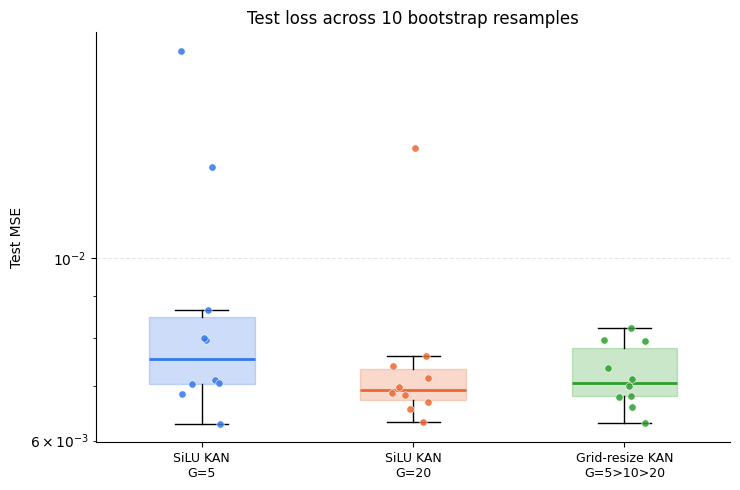

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 5))
bp = ax.boxplot([boot[n] for n in NAMES], positions=range(len(NAMES)), widths=0.5,
                patch_artist=True, showfliers=False)
for patch, n in zip(bp["boxes"], NAMES):
    patch.set_facecolor(COLOR[n]); patch.set_alpha(0.25); patch.set_edgecolor(COLOR[n])
for med, n in zip(bp["medians"], NAMES):
    med.set_color(COLOR[n]); med.set_linewidth(2)
jit = np.random.default_rng(0)
for i, n in enumerate(NAMES):
    ax.scatter(i + jit.uniform(-0.1, 0.1, n_bootstrap), boot[n], color=COLOR[n], s=28, alpha=0.85,
               edgecolors="white", linewidth=0.5, zorder=3)
ax.set_xticks(range(len(NAMES)))
ax.set_xticklabels([CONFIGS[n]["label"].replace(", G=", "\nG=") for n in NAMES], fontsize=9)
ax.set_yscale("log")
ax.set_ylabel("Test MSE")
ax.set_title(f"Test loss across {n_bootstrap} bootstrap resamples")
ax.grid(True, ls="--", alpha=0.3, axis="y")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Data Efficiency

Train on a random fraction of the fit split (without replacement), 2 seeds
per point. Epoch budgets are unchanged, so small fractions get fewer
gradient steps in total; that affects all three configs equally. A finer
grid has more coefficients per edge, so it is the config most exposed to
overfitting when data is scarce.

In [19]:
FRACS = (0.05, 0.1, 0.25, 0.5, 1.0)
DE_SEEDS = (123, 124)
n_fit = x_fit.shape[0]

data_eff = {
    name: {f: np.array([run_cfg(name, seed=s, frac=f)["test_loss"] for s in DE_SEEDS]) for f in FRACS}
    for name in tqdm(NAMES, desc="Data efficiency")
}

print(f"{'frac':>5s} {'n_train':>7s} " + " ".join(f"{n:>10s}" for n in NAMES))
for f in FRACS:
    n_tr = max(int(round(n_fit * f)), 32) if f < 1 else n_fit
    print(f"{f:>5.2f} {n_tr:>7d} " + " ".join(f"{data_eff[n][f].mean():>10.5f}" for n in NAMES))

Data efficiency:   0%|          | 0/3 [00:00<?, ?it/s]

 frac n_train    silu_g5   silu_g20     resize
 0.05     389    0.03810    0.41490    0.02576
 0.10     779    0.03008    0.17699    0.01724
 0.25    1947    0.01685    0.01372    0.01342
 0.50    3894    0.00884    0.00984    0.00859
 1.00    7787    0.00798    0.00879    0.00703


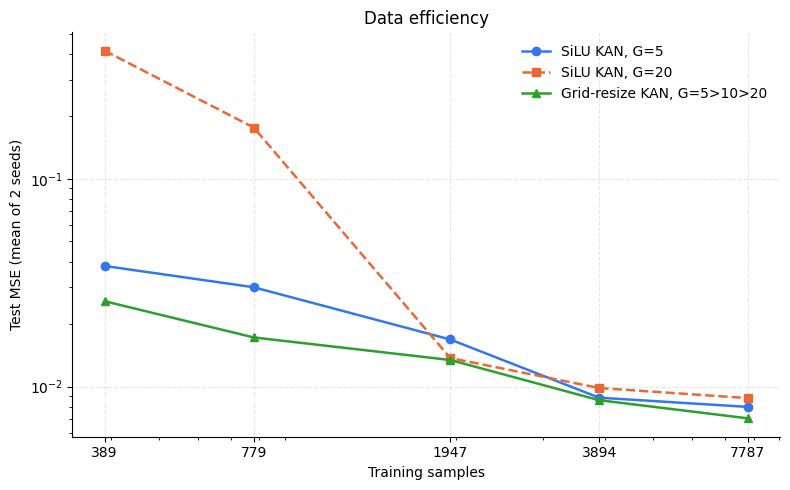

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
n_tr = [max(int(round(n_fit * f)), 32) if f < 1 else n_fit for f in FRACS]
for name in NAMES:
    m = [data_eff[name][f].mean() for f in FRACS]
    ax.plot(n_tr, m, color=COLOR[name], ls=LS[name], marker=MARK[name], lw=1.8, ms=6, label=CONFIGS[name]["label"])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(n_tr)
ax.set_xticklabels(n_tr)
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("Training samples")
ax.set_ylabel("Test MSE (mean of 2 seeds)")
ax.set_title("Data efficiency")
ax.grid(True, ls="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Timing

Two numbers. The wall time in the canonical, ablation and bootstrap tables
above includes JIT compile and early-stopping-dependent epoch counts, so it
is the practical cost. The micro-benchmark below is the clean per-epoch
cost: one discarded warm-up epoch, then 10 timed steady-state epochs, plus
whole-test-set inference through a jitted `fori_loop`.

A resize run uses `silu_g20`'s widths at every stage, so the per-epoch cost
of its early stages is the cost of a coarser grid at that fixed width.
At inference the trained resize model is the same architecture as
`silu_g20`, so it costs the same. Another process was using the GPU while
these were measured, so read ratios between rows, not absolute milliseconds.

In [21]:
def time_config(dims, grid_size, *, n_epoch_time=10, n_repeat_infer=50, batch_size=16, seed=123):
    key = jax.random.PRNGKey(seed)
    params, opt_state, run_epoch, eval_loss = _make_stage(
        dims, grid_size, x_fit, y_fit, batch_size=batch_size, learning_rate=1e-3,
        weight_decay=0.05, init_key=key)
    n = x_fit.shape[0]
    perm = jax.random.permutation(key, n)
    params, opt_state = run_epoch(params, opt_state, perm)  # warm-up (compile)
    jax.block_until_ready(params)
    t0 = time.perf_counter()
    for _ in range(n_epoch_time):
        params, opt_state = run_epoch(params, opt_state, perm)
    jax.block_until_ready(params)
    per_epoch = (time.perf_counter() - t0) / n_epoch_time

    graphdef, p = nnx.split(_kan_ctor(dims, grid_size)(nnx.Rngs(key)), nnx.Param)

    @jax.jit
    def timed_infer(p, n_repeat):
        def body(i, acc):
            pred, _ = nnx.merge(graphdef, p)(x_test_t, train=False)
            return acc + jnp.sum(pred)
        return jax.lax.fori_loop(0, n_repeat, body, 0.0)

    jax.block_until_ready(timed_infer(p, 1))
    t0 = time.perf_counter()
    jax.block_until_ready(timed_infer(p, n_repeat_infer))
    per_infer = (time.perf_counter() - t0) / n_repeat_infer
    return per_epoch, per_infer


timing_rows = [
    ("silu_g5  (G=5,  own width)",  DIMS_BY_G[5],       5),
    ("silu_g20 width, G=5",         DIMS_BY_G[G_FINAL], 5),
    ("silu_g20 width, G=10",        DIMS_BY_G[G_FINAL], 10),
    ("silu_g20 (G=20, own width)",  DIMS_BY_G[G_FINAL], 20),
]
timing = {}
print(f"{'setup':28s} {'params':>8s} {'epoch [ms]':>11s} {'test-set infer [ms]':>20s}")
for label, dims, g in timing_rows:
    pe, pi = time_config(dims, g)
    timing[label] = (pe, pi)
    print(f"{label:28s} {kan_n_params(dims, g):>8d} {pe * 1000:>11.1f} {pi * 1000:>20.3f}")

setup                          params  epoch [ms]  test-set infer [ms]


silu_g5  (G=5,  own width)     335630       169.3                0.898


silu_g20 width, G=5            133020       123.3                0.483


silu_g20 width, G=10           199530       147.5                0.867


silu_g20 (G=20, own width)     332550       225.2                1.345


## Summary

### Findings

Numbers below are from the executed run stored in this notebook. I ran the
whole notebook twice and single-run numbers moved by about 10% with the
same seeds (GPU non-determinism), so only patterns that appeared in both
runs are stated as findings.

- **The resize is exact on nested grids.** Validation loss right after each
  resize equals the previous stage's best to three decimals (1.000x), also
  for the 2 -> 5 step (1.001x). The extra capacity starts as a no-op.
- **Resize beat the same final architecture trained from scratch.** At
  G=20 with identical widths, `5>10>20` had a lower mean test loss than the
  fixed G=20 run in the seed sweep, the schedule ablation and the
  bootstrap, and it was the lowest point in the fixed-grid sweep. The gap is
  0.0003 to 0.0012 against a seed std of 0.0006 to 0.0011, so it is
  suggestive, not settled. In the paired bootstrap it won only 4 to 5 of 10
  resamples against fixed G=20 (difference std 0.0018), which does not
  support a mean win on its own.
- **Resize is steadier.** Its bootstrap std/mean was 13% and 8.5% across the
  two runs, against 20% and 27% for fixed G=20 and 35% to 39% for G=5.
- **Every ladder beat plain `20` in both runs.** The ordering among the
  ladders is noise. `10>20` was the best ladder in one run and the weakest
  in the other.
- **A fixed grid has no clear best size at ~336k params.** G=3 was the worst
  in one run, and the rest sat within about one std of each other. G=40 flipped
  from worst to tied-best between runs.
- **Data efficiency is where the schedule matters most.** Fixed G=20
  collapses at 5% and 10% of the data (test MSE 0.17 to 0.41). Resize at
  the same final architecture stays at 0.017 to 0.026 and beats the G=5
  default there in both runs. From 25% of the data upward the three configs
  are within noise of each other.
- **Cost.** Resize trains about 1.4x longer in wall time in the ablation
  (25 to 26 s against 18 s per run) and up to 2x in single canonical runs,
  because it runs more epochs and pays a JIT compile per stage. The final model also costs more than G=5 at
  the same parameter count: G=20 was about 1.3x slower per training epoch and
  about 1.5x slower at inference than G=5, since every edge evaluates more
  spline bases. Inference cost of the resize model equals fixed G=20.

What this notebook cannot say: whether the gain survives a tuned learning
rate schedule (a decaying rate might close the gap by itself), and whether
adaptive grid placement changes the picture.

In [22]:
def _ms(a):
    return f"{np.mean(a):.5f} +/- {np.std(a):.5f}"

print("1) Canonical (seed 123), test MSE:")
for name in NAMES:
    print(f"   {CONFIGS[name]['label']:28s} {canonical[name]['test_loss']:.5f}  ({canonical[name]['n_params']} params, {canonical[name]['time_s']:.0f}s)")

print("\n2) Fixed-grid sweep, test MSE mean +/- std over 3 seeds:")
for g in GRID_SWEEP:
    print(f"   SiLU G={g:<3d} {_ms([r['test_loss'] for r in sweep[g]])}")
print(f"   Resize 5>10>20 {_ms([r['test_loss'] for r in resize_seeds])}")

print("\n3) Schedule ablation (final G=20), test MSE mean +/- std:")
for k, rs_ in ablation.items():
    print(f"   {k:10s} {_ms([r['test_loss'] for r in rs_])}")

print(f"\n4) Bootstrap (n={n_bootstrap}), test MSE mean +/- std:")
for name in NAMES:
    print(f"   {name:9s} {_ms(boot[name])}")

print("\n5) Data efficiency, test MSE (mean of 2 seeds):")
print(f"   {'frac':>5s} " + " ".join(f"{n:>10s}" for n in NAMES))
for f in FRACS:
    print(f"   {f:>5.2f} " + " ".join(f"{data_eff[n][f].mean():>10.5f}" for n in NAMES))

1) Canonical (seed 123), test MSE:
   SiLU KAN, G=5                0.00714  (335630 params, 24s)
   SiLU KAN, G=20               0.00936  (332550 params, 16s)
   Grid-resize KAN, G=5>10>20   0.00622  (332550 params, 35s)

2) Fixed-grid sweep, test MSE mean +/- std over 3 seeds:
   SiLU G=3   0.00851 +/- 0.00081
   SiLU G=5   0.00767 +/- 0.00081
   SiLU G=10  0.00758 +/- 0.00086
   SiLU G=20  0.00806 +/- 0.00113
   SiLU G=40  0.00757 +/- 0.00051
   Resize 5>10>20 0.00685 +/- 0.00070

3) Schedule ablation (final G=20), test MSE mean +/- std:
   20         0.00806 +/- 0.00113
   10>20      0.00778 +/- 0.00094
   5>10>20    0.00685 +/- 0.00070
   2>5>10>20  0.00665 +/- 0.00014

4) Bootstrap (n=10), test MSE mean +/- std:
   silu_g5   0.00897 +/- 0.00346
   silu_g20  0.00760 +/- 0.00204
   resize    0.00721 +/- 0.00061

5) Data efficiency, test MSE (mean of 2 seeds):
    frac    silu_g5   silu_g20     resize
    0.05    0.03810    0.41490    0.02576
    0.10    0.03008    0.17699    0.01724